In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import time

In [2]:
INPUT_CSV = "../data/comment_threads.csv"

In [3]:
df = pd.read_csv(INPUT_CSV)
df.shape

(19663, 15)

In [4]:
df.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited
0,t3_1oxggea,post,2025-11-15T02:49:46+00:00,flatearth,DeeDaMann,NaN,NaN,Pseudo believers URL: https://i.redd.it/x6gbw...,https://www.reddit.com/r/flatearth/comments/1o...,0,0,0.0,0.47,195.0,False
1,t1_nox2s20,comment,2025-11-15T02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,88,88,NaN,NaN,NaN,False
2,t1_nox5pny,comment,2025-11-15T03:12:27+00:00,flatearth,Just_Ear_2953,t3_1oxggea,post,We HAVE repeatedly observed and measured the c...,https://www.reddit.com/r/flatearth/comments/1o...,112,112,NaN,NaN,NaN,False
3,t1_nox2y8k,comment,2025-11-15T02:54:13+00:00,flatearth,dogsop,t3_1oxggea,post,The stupid part is that it is completely obser...,https://www.reddit.com/r/flatearth/comments/1o...,44,44,NaN,NaN,NaN,False
4,t1_nox4zax,comment,2025-11-15T03:07:31+00:00,flatearth,Polenicus,t3_1oxggea,post,"Ah yes, declaring Science has been scientifica...",https://www.reddit.com/r/flatearth/comments/1o...,36,36,NaN,NaN,NaN,False


## Add post_id to each row

In [5]:
df["post_id"] = np.where(
    df["activity_type"] == "post",
    df["activity_id"],
    np.nan
)
df.head(2)

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id
0,t3_1oxggea,post,2025-11-15T02:49:46+00:00,flatearth,DeeDaMann,NaN,NaN,Pseudo believers URL: https://i.redd.it/x6gbw...,https://www.reddit.com/r/flatearth/comments/1o...,0,0,0.0,0.47,195.0,False,t3_1oxggea
1,t1_nox2s20,comment,2025-11-15T02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,88,88,NaN,NaN,NaN,False,NaN


In [6]:
id_to_post_id = dict(zip(df["activity_id"], df["post_id"]))
changed = True

while changed:
    changed = False
    
    for idx, row in df[df["post_id"].isna()].iterrows():
        parent = row["parent_id"]
        
        if parent in id_to_post_id and pd.notna(id_to_post_id[parent]):
            df.at[idx, "post_id"] = id_to_post_id[parent]
            id_to_post_id[row["activity_id"]] = id_to_post_id[parent]
            changed = True


In [7]:
df[df["post_id"] == 't3_1oxggea'].shape

(190, 16)

In [8]:
df.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id
0,t3_1oxggea,post,2025-11-15T02:49:46+00:00,flatearth,DeeDaMann,NaN,NaN,Pseudo believers URL: https://i.redd.it/x6gbw...,https://www.reddit.com/r/flatearth/comments/1o...,0,0,0.0,0.47,195.0,False,t3_1oxggea
1,t1_nox2s20,comment,2025-11-15T02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,88,88,NaN,NaN,NaN,False,t3_1oxggea
2,t1_nox5pny,comment,2025-11-15T03:12:27+00:00,flatearth,Just_Ear_2953,t3_1oxggea,post,We HAVE repeatedly observed and measured the c...,https://www.reddit.com/r/flatearth/comments/1o...,112,112,NaN,NaN,NaN,False,t3_1oxggea
3,t1_nox2y8k,comment,2025-11-15T02:54:13+00:00,flatearth,dogsop,t3_1oxggea,post,The stupid part is that it is completely obser...,https://www.reddit.com/r/flatearth/comments/1o...,44,44,NaN,NaN,NaN,False,t3_1oxggea
4,t1_nox4zax,comment,2025-11-15T03:07:31+00:00,flatearth,Polenicus,t3_1oxggea,post,"Ah yes, declaring Science has been scientifica...",https://www.reddit.com/r/flatearth/comments/1o...,36,36,NaN,NaN,NaN,False,t3_1oxggea


## dataframe with comment threads

In [9]:
comments_df = df[df["activity_type"] == "comment"].copy()

In [10]:
parent_lookup = dict(zip(df["activity_id"], df["parent_id"]))
timestamp_lookup = dict(zip(df["activity_id"], df["timestamp"]))
type_lookup = dict(zip(df["activity_id"], df["activity_type"]))

In [11]:
def get_parent_comment_chain(comment_id):
    chain = []
    current_parent = parent_lookup.get(comment_id)

    while current_parent and type_lookup.get(current_parent) == "comment":
        chain.append(current_parent)
        current_parent = parent_lookup.get(current_parent)

    return chain[::-1]

In [12]:
comments_df["parent_comments_ids"] = comments_df["activity_id"].apply(
    get_parent_comment_chain
)

In [13]:
comments_df.tail()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,parent_comments_ids
19658,t1_m8354fz,comment,2025-01-20T01:24:16+00:00,flatearth,NaN,t1_m834nb2,comment,There’s plenty of books published about it,https://www.reddit.com/r/flatearth/comments/1i...,1,1,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q..."
19659,t1_m832opp,comment,2025-01-20T01:10:40+00:00,flatearth,NaN,t1_m832fkt,comment,No I’m not I’m being serious and factual sayin...,https://www.reddit.com/r/flatearth/comments/1i...,0,0,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q..."
19660,t1_m848v83,comment,2025-01-20T05:38:57+00:00,flatearth,NaN,t1_m848ekf,comment,Who’s to say that the satellites don’t not go ...,https://www.reddit.com/r/flatearth/comments/1i...,0,0,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q..."
19661,t1_m835xlz,comment,2025-01-20T01:28:42+00:00,flatearth,PerspectiveNarrow890,t1_m8354fz,comment,Ok cool. Are these books factual or theoretica...,https://www.reddit.com/r/flatearth/comments/1i...,6,6,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q..."
19662,t1_m83k40g,comment,2025-01-20T02:47:34+00:00,flatearth,PerspectiveNarrow890,t1_m832opp,comment,How did you come to this conclusion? If you're...,https://www.reddit.com/r/flatearth/comments/1i...,3,3,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q..."


In [14]:
def get_direct_parent_timestamp(comment_id):
    parent = parent_lookup.get(comment_id)
    if type_lookup.get(parent) == "comment":
        return timestamp_lookup.get(parent)
    return pd.NaT

comments_df["parent_comment_timestamp"] = comments_df["activity_id"].apply(
    get_direct_parent_timestamp
)

In [15]:
comments_df.tail()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,parent_comments_ids,parent_comment_timestamp
19658,t1_m8354fz,comment,2025-01-20T01:24:16+00:00,flatearth,NaN,t1_m834nb2,comment,There’s plenty of books published about it,https://www.reddit.com/r/flatearth/comments/1i...,1,1,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20T01:21:33+00:00
19659,t1_m832opp,comment,2025-01-20T01:10:40+00:00,flatearth,NaN,t1_m832fkt,comment,No I’m not I’m being serious and factual sayin...,https://www.reddit.com/r/flatearth/comments/1i...,0,0,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20T01:09:17+00:00
19660,t1_m848v83,comment,2025-01-20T05:38:57+00:00,flatearth,NaN,t1_m848ekf,comment,Who’s to say that the satellites don’t not go ...,https://www.reddit.com/r/flatearth/comments/1i...,0,0,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20T05:35:13+00:00
19661,t1_m835xlz,comment,2025-01-20T01:28:42+00:00,flatearth,PerspectiveNarrow890,t1_m8354fz,comment,Ok cool. Are these books factual or theoretica...,https://www.reddit.com/r/flatearth/comments/1i...,6,6,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20T01:24:16+00:00
19662,t1_m83k40g,comment,2025-01-20T02:47:34+00:00,flatearth,PerspectiveNarrow890,t1_m832opp,comment,How did you come to this conclusion? If you're...,https://www.reddit.com/r/flatearth/comments/1i...,3,3,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20T01:10:40+00:00


# Posts analysis

In [16]:
df.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id
0,t3_1oxggea,post,2025-11-15T02:49:46+00:00,flatearth,DeeDaMann,NaN,NaN,Pseudo believers URL: https://i.redd.it/x6gbw...,https://www.reddit.com/r/flatearth/comments/1o...,0,0,0.0,0.47,195.0,False,t3_1oxggea
1,t1_nox2s20,comment,2025-11-15T02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,88,88,NaN,NaN,NaN,False,t3_1oxggea
2,t1_nox5pny,comment,2025-11-15T03:12:27+00:00,flatearth,Just_Ear_2953,t3_1oxggea,post,We HAVE repeatedly observed and measured the c...,https://www.reddit.com/r/flatearth/comments/1o...,112,112,NaN,NaN,NaN,False,t3_1oxggea
3,t1_nox2y8k,comment,2025-11-15T02:54:13+00:00,flatearth,dogsop,t3_1oxggea,post,The stupid part is that it is completely obser...,https://www.reddit.com/r/flatearth/comments/1o...,44,44,NaN,NaN,NaN,False,t3_1oxggea
4,t1_nox4zax,comment,2025-11-15T03:07:31+00:00,flatearth,Polenicus,t3_1oxggea,post,"Ah yes, declaring Science has been scientifica...",https://www.reddit.com/r/flatearth/comments/1o...,36,36,NaN,NaN,NaN,False,t3_1oxggea


In [17]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
comments = df[df['activity_type'] == 'comment'].copy()

In [18]:
comments['time_bin'] = comments['timestamp'].dt.floor('1H')

counts = (
    comments
    .groupby(['post_id', 'time_bin'])
    .size()
    .rename('n_comments')
    .reset_index()
)

counts['increase'] = (
    counts
    .groupby('post_id')['n_comments']
    .diff()
    .fillna(counts['n_comments'])
)

C:\Users\marci\AppData\Local\Temp\ipykernel_24948\1212968803.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  comments['time_bin'] = comments['timestamp'].dt.floor('1H')


In [41]:
comments.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,time_bin
1,t1_nox2s20,comment,2025-11-15 02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,88,88,NaN,NaN,NaN,False,t3_1oxggea,2025-11-15 02:00:00+00:00
2,t1_nox5pny,comment,2025-11-15 03:12:27+00:00,flatearth,Just_Ear_2953,t3_1oxggea,post,We HAVE repeatedly observed and measured the c...,https://www.reddit.com/r/flatearth/comments/1o...,112,112,NaN,NaN,NaN,False,t3_1oxggea,2025-11-15 03:00:00+00:00
3,t1_nox2y8k,comment,2025-11-15 02:54:13+00:00,flatearth,dogsop,t3_1oxggea,post,The stupid part is that it is completely obser...,https://www.reddit.com/r/flatearth/comments/1o...,44,44,NaN,NaN,NaN,False,t3_1oxggea,2025-11-15 02:00:00+00:00
4,t1_nox4zax,comment,2025-11-15 03:07:31+00:00,flatearth,Polenicus,t3_1oxggea,post,"Ah yes, declaring Science has been scientifica...",https://www.reddit.com/r/flatearth/comments/1o...,36,36,NaN,NaN,NaN,False,t3_1oxggea,2025-11-15 03:00:00+00:00
5,t1_nox650j,comment,2025-11-15 03:15:20+00:00,flatearth,CoolNotice881,t3_1oxggea,post,The upper part is true if it's a few meters la...,https://www.reddit.com/r/flatearth/comments/1o...,30,30,NaN,NaN,NaN,False,t3_1oxggea,2025-11-15 03:00:00+00:00


In [19]:
counts.head()

,post_id,time_bin,n_comments,increase
0,t3_1001upd,2022-12-31 19:00:00+00:00,3,3.0
1,t3_1001upd,2022-12-31 20:00:00+00:00,4,1.0
2,t3_1001upd,2022-12-31 21:00:00+00:00,2,-2.0
3,t3_1001upd,2022-12-31 22:00:00+00:00,2,0.0
4,t3_1001upd,2022-12-31 23:00:00+00:00,2,0.0


In [37]:
sth = df.copy()
df.head(2)

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id
0,t3_1oxggea,post,2025-11-15 02:49:46+00:00,flatearth,DeeDaMann,NaN,NaN,Pseudo believers URL: https://i.redd.it/x6gbw...,https://www.reddit.com/r/flatearth/comments/1o...,0,0,0.0,0.47,195.0,False,t3_1oxggea
1,t1_nox2s20,comment,2025-11-15 02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,88,88,NaN,NaN,NaN,False,t3_1oxggea


In [69]:
from collections import defaultdict

def get_max_depth(comments_dataframe, post_id):
    children = defaultdict(list)

    for _, row in comments_dataframe.iterrows():
        children[row['parent_id']].append(row['activity_id'])

    def max_depth(node_id, depth=0):
        if node_id not in children:
            return depth
        return max(max_depth(child, depth + 1) for child in children[node_id])

    return max_depth(post_id)

def calculate_post_temperature_to_timestamp(post_id, timestamp):
    _counts = counts[(counts['post_id'] == post_id) & (counts['time_bin'] <= timestamp.floor('1h'))]

    comment_growth = (
        _counts[_counts['post_id'] == post_id]
        .groupby('post_id')
        .agg(
            highest_increase=('increase', 'max'),
        )
    )

    _comments = comments[(comments['post_id'] == post_id) & (comments['time_bin'] <= timestamp.floor('1h'))]

    unique_users = (
        _comments
        .groupby('post_id')['author']
        .nunique()
        .rename('num_unique_commenters')
    )

    max_depth = get_max_depth(_comments, post_id)
    max_depth_series = pd.Series({post_id: max_depth}, name='max_thread_depth')

    reply_counts = (
        _comments
        .groupby('parent_id')
        .size()
        .rename('n_replies')
    )

    reply_counts = reply_counts.to_frame()
    reply_counts['forks'] = reply_counts['n_replies'].clip(lower=1) - 1

    _comment_to_post = _comments.set_index('activity_id')['post_id']
    reply_counts['post_id'] = reply_counts.index.map(_comment_to_post)

    forks_per_post = (
        reply_counts
        .groupby('post_id')['forks']
        .sum()
        .rename('num_forks')
    )

    return comment_growth.join(unique_users).join(max_depth_series).join(forks_per_post).fillna(0)



In [20]:
comment_growth = (
    counts
    .groupby('post_id')
    .agg(
        highest_increase=('increase', 'max'),
    )
)
comment_growth.head()

,highest_increase
post_id,
t3_1001upd,3.0
t3_10luxge,13.0
t3_10py2rr,4.0
t3_10wkhmf,43.0
t3_11n6xwg,17.0


In [21]:
comment_growth.shape

(428, 1)

In [22]:
unique_users = (
    comments
    .groupby('post_id')['author']
    .nunique()
    .rename('num_unique_commenters')
)
unique_users.head()

post_id
t3_1001upd     7
t3_10luxge    28
t3_10py2rr    10
t3_10wkhmf    48
t3_11n6xwg    36
Name: num_unique_commenters, dtype: int64

In [23]:
from collections import defaultdict

children = defaultdict(list)

for _, row in comments.iterrows():
    children[row['parent_id']].append(row['activity_id'])

def max_depth(node_id, depth=0):
    if node_id not in children:
        return depth
    return max(max_depth(child, depth + 1) for child in children[node_id])

post_depths = {}

for post_id in comments['post_id'].unique():
    post_depths[post_id] = max_depth(post_id)

depth_series = pd.Series(post_depths, name='max_thread_depth')

In [24]:
depth_series

t3_1oxggea     9
t3_1n2wnk7     8
t3_1jbmwcm     8
t3_1iaro9l     5
t3_1id7872    10
              ..
t3_uv0imm     12
t3_ut6zkg      4
t3_7qfzfg      2
t3_8f509v      5
t3_1i5bsnj    11
Name: max_thread_depth, Length: 428, dtype: int64

In [25]:
reply_counts = (
    comments
    .groupby('parent_id')
    .size()
    .rename('n_replies')
)

reply_counts = reply_counts.to_frame()
reply_counts['forks'] = reply_counts['n_replies'].clip(lower=1) - 1
reply_counts.head()

,n_replies,forks
parent_id,,
t1_cvlkk0o,2,1
t1_cvlliuw,1,0
t1_cw82ywv,1,0
t1_cw862tj,2,1
t1_cw8d3fg,1,0


In [26]:
comment_to_post = comments.set_index('activity_id')['post_id']
reply_counts['post_id'] = reply_counts.index.map(comment_to_post)

forks_per_post = (
    reply_counts
    .groupby('post_id')['forks']
    .sum()
    .rename('num_forks')
)
forks_per_post.head()

post_id
t3_1001upd     2
t3_10luxge    18
t3_10py2rr     0
t3_10wkhmf    46
t3_11n6xwg    38
Name: num_forks, dtype: int64

In [27]:
post_discussion_temperature = (
    comment_growth
    .join(unique_users)
    .join(depth_series)
    .join(forks_per_post)
    .fillna(0)
)

In [55]:
# df[df['activity_id'] == 't3_1001upd']
df.iloc[18803]

activity_id                                             t3_1001upd
activity_type                                                 post
timestamp                                2022-12-31 19:38:20+00:00
subreddit                                                flatearth
author                                                       jjns_
parent_id                                                      NaN
parent_type                                                    NaN
content              Cum  URL: https://i.redd.it/8xhswh3avb9a1.jpg
permalink        https://www.reddit.com/r/flatearth/comments/10...
score                                                            3
upvotes                                                          3
downvotes                                                      0.0
upvote_ratio                                                  0.56
num_comments                                                  16.0
edited                                                       F

In [68]:
calculate_post_temperature_to_timestamp('t3_1001upd', pd.to_datetime('2022-12-31 19:38:20+00:00'))

,highest_increase,num_unique_commenters,max_thread_depth,num_forks
post_id,,,,
t3_1001upd,3.0,2,2,0


In [70]:
post_discussion_temperature.head()

,highest_increase,num_unique_commenters,max_thread_depth,num_forks
post_id,,,,
t3_1001upd,3.0,7,5,2.0
t3_10luxge,13.0,28,6,18.0
t3_10py2rr,4.0,10,6,0.0
t3_10wkhmf,43.0,48,14,46.0
t3_11n6xwg,17.0,36,18,38.0


In [71]:
posts_df = df[df["activity_type"] == "post"].copy()
posts_df.shape

(436, 16)

In [72]:
post_discussion_temperature.head()

,highest_increase,num_unique_commenters,max_thread_depth,num_forks
post_id,,,,
t3_1001upd,3.0,7,5,2.0
t3_10luxge,13.0,28,6,18.0
t3_10py2rr,4.0,10,6,0.0
t3_10wkhmf,43.0,48,14,46.0
t3_11n6xwg,17.0,36,18,38.0


In [73]:
posts_with_temperature = posts_df.merge(
    post_discussion_temperature,
    left_on='activity_id',
    right_index=True,
    how='left'
)
posts_with_temperature.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,highest_increase,num_unique_commenters,max_thread_depth,num_forks
0,t3_1oxggea,post,2025-11-15 02:49:46+00:00,flatearth,DeeDaMann,NaN,NaN,Pseudo believers URL: https://i.redd.it/x6gbw...,https://www.reddit.com/r/flatearth/comments/1o...,0,0,0.0,0.47,195.0,False,t3_1oxggea,47.0,112.0,9.0,70.0
190,t3_1n2wnk7,post,2025-08-29 03:21:08+00:00,flatearth,Hey_There_Cowboy,NaN,NaN,Water cant stick to a ball! Fight me! Water c...,https://www.reddit.com/r/flatearth/comments/1n...,10,10,0.0,0.53,201.0,False,t3_1n2wnk7,12.0,110.0,8.0,28.0
384,t3_1jbmwcm,post,2025-03-15 04:11:30+00:00,flatearth,Iwinloser,NaN,NaN,Another prominent genius and model Tila Tequil...,https://www.reddit.com/r/flatearth/comments/1j...,11,11,0.0,0.53,148.0,False,t3_1jbmwcm,11.0,113.0,8.0,14.0
520,t3_1iaro9l,post,2025-01-26 21:56:06+00:00,flatearth,Iwinloser,NaN,NaN,NASA fired a missile at leading scientist to s...,https://www.reddit.com/r/flatearth/comments/1i...,1,1,0.0,0.50,59.0,False,t3_1iaro9l,17.0,41.0,5.0,13.0
579,t3_1id7872,post,2025-01-29 22:56:11+00:00,flatearth,PlayfulAd1711,NaN,NaN,I am a ball earth like most people on this sub...,https://www.reddit.com/r/flatearth/comments/1i...,19,19,0.0,0.55,263.0,False,t3_1id7872,59.0,163.0,10.0,66.0


In [74]:
posts_with_temperature = posts_with_temperature[posts_with_temperature['num_comments'] != 0]
posts_with_temperature.shape

(428, 20)

In [75]:
posts_with_temperature[posts_with_temperature['num_forks'].isna()]

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,highest_increase,num_unique_commenters,max_thread_depth,num_forks


In [62]:
posts_with_temperature.to_csv("../data/posts_with_temperature.csv", index=False)

In [63]:
posts_with_temperature.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,highest_increase,num_unique_commenters,max_thread_depth,num_forks
0,t3_1oxggea,post,2025-11-15 02:49:46+00:00,flatearth,DeeDaMann,NaN,NaN,Pseudo believers URL: https://i.redd.it/x6gbw...,https://www.reddit.com/r/flatearth/comments/1o...,0,0,0.0,0.47,195.0,False,t3_1oxggea,47.0,112.0,9.0,70.0
190,t3_1n2wnk7,post,2025-08-29 03:21:08+00:00,flatearth,Hey_There_Cowboy,NaN,NaN,Water cant stick to a ball! Fight me! Water c...,https://www.reddit.com/r/flatearth/comments/1n...,10,10,0.0,0.53,201.0,False,t3_1n2wnk7,12.0,110.0,8.0,28.0
384,t3_1jbmwcm,post,2025-03-15 04:11:30+00:00,flatearth,Iwinloser,NaN,NaN,Another prominent genius and model Tila Tequil...,https://www.reddit.com/r/flatearth/comments/1j...,11,11,0.0,0.53,148.0,False,t3_1jbmwcm,11.0,113.0,8.0,14.0
520,t3_1iaro9l,post,2025-01-26 21:56:06+00:00,flatearth,Iwinloser,NaN,NaN,NASA fired a missile at leading scientist to s...,https://www.reddit.com/r/flatearth/comments/1i...,1,1,0.0,0.50,59.0,False,t3_1iaro9l,17.0,41.0,5.0,13.0
579,t3_1id7872,post,2025-01-29 22:56:11+00:00,flatearth,PlayfulAd1711,NaN,NaN,I am a ball earth like most people on this sub...,https://www.reddit.com/r/flatearth/comments/1i...,19,19,0.0,0.55,263.0,False,t3_1id7872,59.0,163.0,10.0,66.0


## Metric for temperature discussion under posts

It should include:
1. Volume & Participation - how many people are involved (number of comments, number of users engaged in the discussion)
2. Temporal Escalation - how fast the discussion heats up (highest increase of comments per hour)
3. Structure - how deep are the commen threads, how many comment forks

## Discussion Temperature Score

We define the following log-transformed variables:

V = log(1 + num_comments)  
P = log(1 + num_unique_commenters)  
E = log(1 + highest_increase)  
D = log(1 + max_thread_depth)  
F = log(1 + num_forks)

---

## Normalization

Each component is normalized to the range [0,1] using min–max normalization:

X_norm = (X - min(X)) / (max(X) - min(X))

where X ∈ {V, P, E, D, F}.

---

## Final Temperature Score

The Discussion Temperature Score is defined as:

Temperature = 0.25 * V + 0.20 * P + 0.20 * E + 0.20 * D + 0.15 * F

---

## Rationale for Weights

| Component | Weight | Reason |
|----------|--------|--------|
| Volume (V) | 0.25 | Baseline intensity |
| Participation (P) | 0.20 | Collective engagement |
| Escalation (E) | 0.20 | Sudden conflict |
| Depth (D) | 0.20 | Prolonged argument |
| Forks (F) | 0.15 | Controversy |


In [205]:
posts_with_temperature.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,highest_increase,num_unique_commenters,max_thread_depth,num_forks
0,t3_1oxggea,post,2025-11-15 02:49:46+00:00,flatearth,DeeDaMann,NaN,NaN,Pseudo believers URL: https://i.redd.it/x6gbw...,https://www.reddit.com/r/flatearth/comments/1o...,0,0,0.0,0.47,195.0,False,t3_1oxggea,47.0,112.0,9.0,70.0
190,t3_1n2wnk7,post,2025-08-29 03:21:08+00:00,flatearth,Hey_There_Cowboy,NaN,NaN,Water cant stick to a ball! Fight me! Water c...,https://www.reddit.com/r/flatearth/comments/1n...,10,10,0.0,0.53,201.0,False,t3_1n2wnk7,12.0,110.0,8.0,28.0
384,t3_1jbmwcm,post,2025-03-15 04:11:30+00:00,flatearth,Iwinloser,NaN,NaN,Another prominent genius and model Tila Tequil...,https://www.reddit.com/r/flatearth/comments/1j...,11,11,0.0,0.53,148.0,False,t3_1jbmwcm,11.0,113.0,8.0,14.0
520,t3_1iaro9l,post,2025-01-26 21:56:06+00:00,flatearth,Iwinloser,NaN,NaN,NASA fired a missile at leading scientist to s...,https://www.reddit.com/r/flatearth/comments/1i...,1,1,0.0,0.50,59.0,False,t3_1iaro9l,17.0,41.0,5.0,13.0
579,t3_1id7872,post,2025-01-29 22:56:11+00:00,flatearth,PlayfulAd1711,NaN,NaN,I am a ball earth like most people on this sub...,https://www.reddit.com/r/flatearth/comments/1i...,19,19,0.0,0.55,263.0,False,t3_1id7872,59.0,163.0,10.0,66.0


In [77]:
comments_df.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,parent_comments_ids,parent_comment_timestamp
1,t1_nox2s20,comment,2025-11-15T02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,88,88,NaN,NaN,NaN,False,t3_1oxggea,[],NaT
2,t1_nox5pny,comment,2025-11-15T03:12:27+00:00,flatearth,Just_Ear_2953,t3_1oxggea,post,We HAVE repeatedly observed and measured the c...,https://www.reddit.com/r/flatearth/comments/1o...,112,112,NaN,NaN,NaN,False,t3_1oxggea,[],NaT
3,t1_nox2y8k,comment,2025-11-15T02:54:13+00:00,flatearth,dogsop,t3_1oxggea,post,The stupid part is that it is completely obser...,https://www.reddit.com/r/flatearth/comments/1o...,44,44,NaN,NaN,NaN,False,t3_1oxggea,[],NaT
4,t1_nox4zax,comment,2025-11-15T03:07:31+00:00,flatearth,Polenicus,t3_1oxggea,post,"Ah yes, declaring Science has been scientifica...",https://www.reddit.com/r/flatearth/comments/1o...,36,36,NaN,NaN,NaN,False,t3_1oxggea,[],NaT
5,t1_nox650j,comment,2025-11-15T03:15:20+00:00,flatearth,CoolNotice881,t3_1oxggea,post,The upper part is true if it's a few meters la...,https://www.reddit.com/r/flatearth/comments/1o...,30,30,NaN,NaN,NaN,False,t3_1oxggea,[],NaT


In [64]:
from sklearn.preprocessing import MinMaxScaler

_df = posts_with_temperature.copy()

features = [
    'num_comments',
    'highest_increase',
    'num_unique_commenters',
    'max_thread_depth',
    'num_forks'
]

for col in features:
    _df[f'{col}_log'] = np.log1p(_df[col])

scaler = MinMaxScaler()
log_cols = [f'{c}_log' for c in features]
_df[log_cols] = scaler.fit_transform(_df[log_cols])

weights = {
    'num_comments_log': 0.25,
    'num_unique_commenters_log': 0.20,
    'highest_increase_log': 0.20,
    'max_thread_depth_log': 0.20,
    'num_forks_log': 0.15
}

_df['discussion_temperature'] = sum(
    _df[col] * w for col, w in weights.items()
)
_df.head()


,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,...,highest_increase,num_unique_commenters,max_thread_depth,num_forks,num_comments_log,highest_increase_log,num_unique_commenters_log,max_thread_depth_log,num_forks_log,discussion_temperature
0,t3_1oxggea,post,2025-11-15 02:49:46+00:00,flatearth,DeeDaMann,NaN,NaN,Pseudo believers URL: https://i.redd.it/x6gbw...,https://www.reddit.com/r/flatearth/comments/1o...,0,...,47.0,112.0,9.0,70.0,0.737299,0.880124,0.838964,0.323843,0.861363,0.722115
190,t3_1n2wnk7,post,2025-08-29 03:21:08+00:00,flatearth,Hey_There_Cowboy,NaN,NaN,Water cant stick to a ball! Fight me! Water c...,https://www.reddit.com/r/flatearth/comments/1n...,10,...,12.0,110.0,8.0,28.0,0.742148,0.518373,0.835795,0.302643,0.680432,0.618964
384,t3_1jbmwcm,post,2025-03-15 04:11:30+00:00,flatearth,Iwinloser,NaN,NaN,Another prominent genius and model Tila Tequil...,https://www.reddit.com/r/flatearth/comments/1j...,11,...,11.0,113.0,8.0,14.0,0.693211,0.496206,0.840528,0.302643,0.547218,0.583261
520,t3_1iaro9l,post,2025-01-26 21:56:06+00:00,flatearth,Iwinloser,NaN,NaN,NASA fired a missile at leading scientist to s...,https://www.reddit.com/r/flatearth/comments/1i...,1,...,17.0,41.0,5.0,13.0,0.546939,0.608495,0.663320,0.221057,0.533276,0.515301
579,t3_1id7872,post,2025-01-29 22:56:11+00:00,flatearth,PlayfulAd1711,NaN,NaN,I am a ball earth like most people on this sub...,https://www.reddit.com/r/flatearth/comments/1i...,19,...,59.0,163.0,10.0,66.0,0.785193,0.941920,0.905068,0.343021,0.849646,0.761747


In [78]:
calculate_post_temperature_to_timestamp('t3_1001upd', pd.to_datetime('2022-12-31 19:38:20+00:00'))

,highest_increase,num_unique_commenters,max_thread_depth,num_forks
post_id,,,,
t3_1001upd,3.0,2,2,0


In [93]:
get_temp_metric_to_timestamp('t3_1001upd', pd.to_datetime('2022-12-31 19:38:20+00:00'))

post_id
t3_1001upd    0.716704
dtype: float64

In [85]:
comments_df['timestamp'] = pd.to_datetime(comments_df['timestamp'])

In [91]:

from sklearn.preprocessing import MinMaxScaler

def get_temp_metric_to_timestamp(post_id, timestamp):
    features = [
        'num_comments',
        'highest_increase',
        'num_unique_commenters',
        'max_thread_depth',
        'num_forks'
    ]

    _df = calculate_post_temperature_to_timestamp(post_id, timestamp)
    _comments = comments_df[(comments_df['post_id'] == post_id) & (comments_df['timestamp'] <= timestamp)]
    _df['num_comments'] = len(_comments)
    
    for col in features:
        _df[f'{col}_log'] = np.log1p(_df[col])

    weights = {
        'num_comments_log': 0.25,
        'num_unique_commenters_log': 0.20,
        'highest_increase_log': 0.20,
        'max_thread_depth_log': 0.20,
        'num_forks_log': 0.15
    }

    return sum(
        _df[col] * w for col, w in weights.items()
    )
    

In [65]:
posts_with_temperature_scores = _df

In [69]:
posts_with_temperature_scores[[
    'num_comments',
    'highest_increase',
    'num_unique_commenters',
    'max_thread_depth',
    'num_forks',
    'discussion_temperature'
]].sort_values('discussion_temperature', ascending=False).head(10)

,num_comments,highest_increase,num_unique_commenters,max_thread_depth,num_forks,discussion_temperature
10086,1003.0,61.0,60.0,287.0,73.0,0.916570
5158,423.0,73.0,55.0,44.0,131.0,0.831518
17924,422.0,40.0,208.0,15.0,105.0,0.797199
3989,500.0,18.0,279.0,16.0,140.0,0.782870
579,263.0,59.0,163.0,10.0,66.0,0.761747
14826,297.0,32.0,94.0,28.0,61.0,0.750786
8550,478.0,19.0,57.0,39.0,89.0,0.748853
6746,219.0,41.0,132.0,14.0,63.0,0.738318
0,195.0,47.0,112.0,9.0,70.0,0.722115
13567,235.0,43.0,48.0,14.0,46.0,0.698918


In [ ]:
posts_with_temperature_scores[[
    'num_comments',
    'highest_increase',
    'num_unique_commenters',
    'max_thread_depth',
    'num_forks',
    'discussion_temperature'
]].sort_values('discussion_temperature', ascending=True).head(10)

,num_comments,highest_increase,num_unique_commenters,max_thread_depth,num_forks,discussion_temperature
16212,1.0,1.0,0.0,1.0,0.0,0.000000
17626,1.0,1.0,0.0,1.0,0.0,0.000000
15433,1.0,1.0,1.0,1.0,0.0,0.024602
15218,1.0,1.0,1.0,1.0,0.0,0.024602
15143,1.0,1.0,1.0,1.0,0.0,0.024602
16022,1.0,1.0,1.0,1.0,0.0,0.024602
13891,1.0,1.0,1.0,1.0,0.0,0.024602
17601,2.0,1.0,1.0,1.0,0.0,0.040903
17337,2.0,1.0,2.0,1.0,0.0,0.055294
4884,2.0,1.0,2.0,1.0,0.0,0.055294


In [78]:
posts_with_temperature_scores.sort_values('discussion_temperature', ascending=False)['activity_id']

10086    t3_1o9zok1
5158     t3_181ravl
17924    t3_16o8us1
3989     t3_1k0u1bt
579      t3_1id7872
            ...    
15218     t3_il9rnv
15433     t3_8dnkgk
16022    t3_1kcdeyy
16212     t3_8ss4n8
17626     t3_8yoopf
Name: activity_id, Length: 428, dtype: object

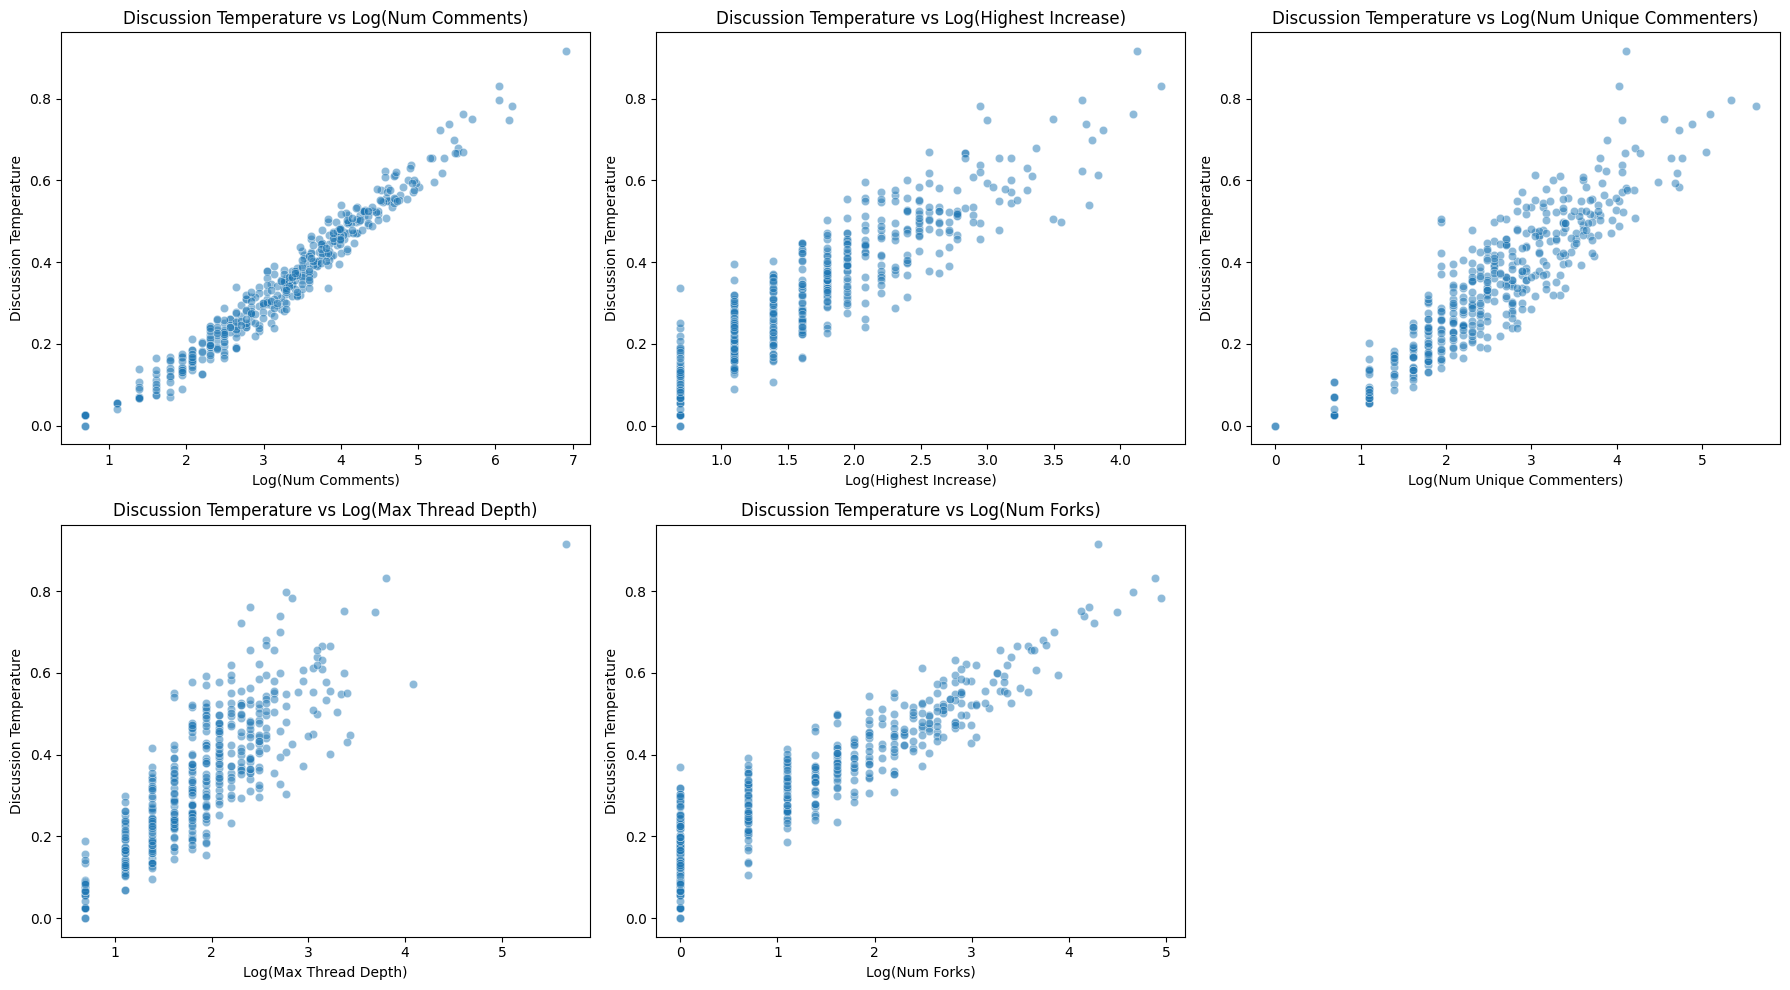

In [271]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_plot = posts_with_temperature_scores[['discussion_temperature', 
                                  'num_comments', 
                                  'highest_increase', 
                                  'num_unique_commenters', 
                                  'max_thread_depth', 
                                  'num_forks']].copy()

df_plot['num_comments_log'] = np.log1p(df_plot['num_comments'])
df_plot['highest_increase_log'] = np.log1p(df_plot['highest_increase'])
df_plot['num_unique_commenters_log'] = np.log1p(df_plot['num_unique_commenters'])
df_plot['max_thread_depth_log'] = np.log1p(df_plot['max_thread_depth'])
df_plot['num_forks_log'] = np.log1p(df_plot['num_forks'])

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

features = ['num_comments_log', 'highest_increase_log', 'num_unique_commenters_log',
            'max_thread_depth_log', 'num_forks_log']
labels = ['Log(Num Comments)', 'Log(Highest Increase)', 'Log(Num Unique Commenters)',
          'Log(Max Thread Depth)', 'Log(Num Forks)']

for i, (feat, label) in enumerate(zip(features, labels)):
    sns.scatterplot(
        x=feat, y='discussion_temperature', data=df_plot, ax=axes[i], alpha=0.5
    )
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Discussion Temperature')
    axes[i].set_title(f'Discussion Temperature vs {label}')

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


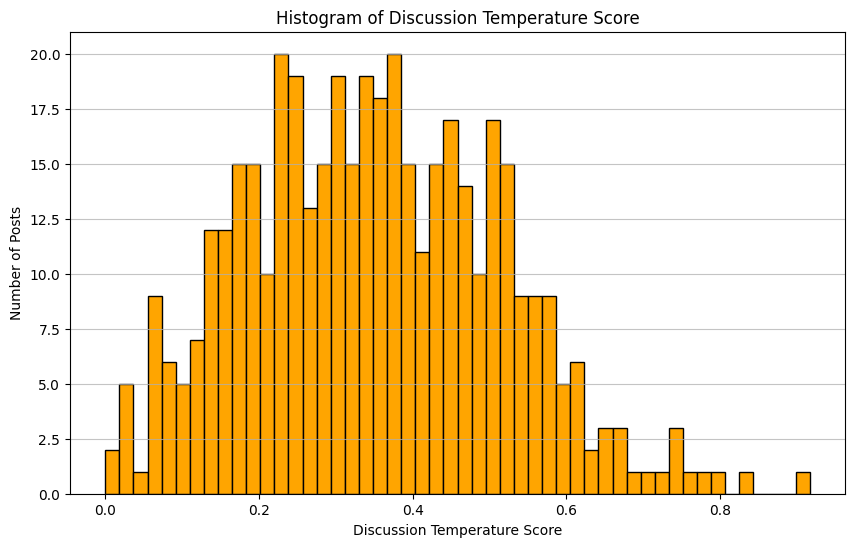

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(posts_with_temperature_scores['discussion_temperature'], bins=50, color='orange', edgecolor='black')
plt.title('Histogram of Discussion Temperature Score')
plt.xlabel('Discussion Temperature Score')
plt.ylabel('Number of Posts')
plt.grid(axis='y', alpha=0.75)
plt.show()

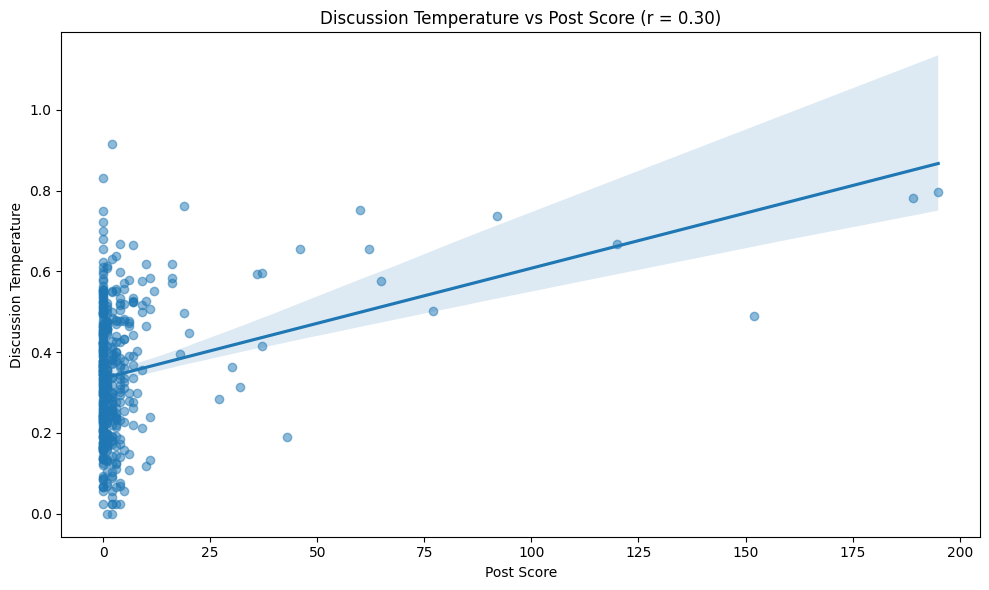

In [280]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

df_plot = posts_with_temperature_scores[['discussion_temperature', 'score']].copy()

df_plot['score_log'] = np.log1p(df_plot['score'].clip(lower=0))

corr, p_value = pearsonr(df_plot['score'], df_plot['discussion_temperature'])

plt.figure(figsize=(10,6))
sns.regplot(
    x='score', y='discussion_temperature', data=df_plot, scatter_kws={'alpha':0.5}
)
plt.xlabel("Post Score")
plt.ylabel("Discussion Temperature")
plt.title(f"Discussion Temperature vs Post Score (r = {corr:.2f})")
plt.tight_layout()
plt.show()


# Comments analysis

In [79]:
comments_df.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,parent_comments_ids,parent_comment_timestamp
1,t1_nox2s20,comment,2025-11-15T02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,88,88,NaN,NaN,NaN,False,t3_1oxggea,[],NaT
2,t1_nox5pny,comment,2025-11-15T03:12:27+00:00,flatearth,Just_Ear_2953,t3_1oxggea,post,We HAVE repeatedly observed and measured the c...,https://www.reddit.com/r/flatearth/comments/1o...,112,112,NaN,NaN,NaN,False,t3_1oxggea,[],NaT
3,t1_nox2y8k,comment,2025-11-15T02:54:13+00:00,flatearth,dogsop,t3_1oxggea,post,The stupid part is that it is completely obser...,https://www.reddit.com/r/flatearth/comments/1o...,44,44,NaN,NaN,NaN,False,t3_1oxggea,[],NaT
4,t1_nox4zax,comment,2025-11-15T03:07:31+00:00,flatearth,Polenicus,t3_1oxggea,post,"Ah yes, declaring Science has been scientifica...",https://www.reddit.com/r/flatearth/comments/1o...,36,36,NaN,NaN,NaN,False,t3_1oxggea,[],NaT
5,t1_nox650j,comment,2025-11-15T03:15:20+00:00,flatearth,CoolNotice881,t3_1oxggea,post,The upper part is true if it's a few meters la...,https://www.reddit.com/r/flatearth/comments/1o...,30,30,NaN,NaN,NaN,False,t3_1oxggea,[],NaT


In [81]:
comments = comments_df.copy()

reply_counts = (
    comments
    .groupby('parent_id')
    .size()
    .rename('num_replies')
)

comments = comments.merge(
    reply_counts,
    left_on='activity_id',
    right_index=True,
    how='left'
)

comments['num_replies'] = comments['num_replies'].fillna(0)
comments.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,parent_comments_ids,parent_comment_timestamp,num_replies
1,t1_nox2s20,comment,2025-11-15T02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,88,88,NaN,NaN,NaN,False,t3_1oxggea,[],NaT,2.0
2,t1_nox5pny,comment,2025-11-15T03:12:27+00:00,flatearth,Just_Ear_2953,t3_1oxggea,post,We HAVE repeatedly observed and measured the c...,https://www.reddit.com/r/flatearth/comments/1o...,112,112,NaN,NaN,NaN,False,t3_1oxggea,[],NaT,4.0
3,t1_nox2y8k,comment,2025-11-15T02:54:13+00:00,flatearth,dogsop,t3_1oxggea,post,The stupid part is that it is completely obser...,https://www.reddit.com/r/flatearth/comments/1o...,44,44,NaN,NaN,NaN,False,t3_1oxggea,[],NaT,1.0
4,t1_nox4zax,comment,2025-11-15T03:07:31+00:00,flatearth,Polenicus,t3_1oxggea,post,"Ah yes, declaring Science has been scientifica...",https://www.reddit.com/r/flatearth/comments/1o...,36,36,NaN,NaN,NaN,False,t3_1oxggea,[],NaT,0.0
5,t1_nox650j,comment,2025-11-15T03:15:20+00:00,flatearth,CoolNotice881,t3_1oxggea,post,The upper part is true if it's a few meters la...,https://www.reddit.com/r/flatearth/comments/1o...,30,30,NaN,NaN,NaN,False,t3_1oxggea,[],NaT,0.0


In [ ]:
comments['timestamp'] = pd.to_datetime(comments['timestamp'])
comments['parent_comment_timestamp'] = pd.to_datetime(
    comments['parent_comment_timestamp']
)

comments['reply_delay_sec'] = (
    comments['timestamp'] - comments['parent_comment_timestamp']
).dt.total_seconds()


In [85]:
comments.tail()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,parent_comments_ids,parent_comment_timestamp,num_replies,reply_delay_sec
19658,t1_m8354fz,comment,2025-01-20 01:24:16+00:00,flatearth,NaN,t1_m834nb2,comment,There’s plenty of books published about it,https://www.reddit.com/r/flatearth/comments/1i...,1,1,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 01:21:33+00:00,1.0,163.0
19659,t1_m832opp,comment,2025-01-20 01:10:40+00:00,flatearth,NaN,t1_m832fkt,comment,No I’m not I’m being serious and factual sayin...,https://www.reddit.com/r/flatearth/comments/1i...,0,0,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 01:09:17+00:00,1.0,83.0
19660,t1_m848v83,comment,2025-01-20 05:38:57+00:00,flatearth,NaN,t1_m848ekf,comment,Who’s to say that the satellites don’t not go ...,https://www.reddit.com/r/flatearth/comments/1i...,0,0,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 05:35:13+00:00,0.0,224.0
19661,t1_m835xlz,comment,2025-01-20 01:28:42+00:00,flatearth,PerspectiveNarrow890,t1_m8354fz,comment,Ok cool. Are these books factual or theoretica...,https://www.reddit.com/r/flatearth/comments/1i...,6,6,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 01:24:16+00:00,0.0,266.0
19662,t1_m83k40g,comment,2025-01-20 02:47:34+00:00,flatearth,PerspectiveNarrow890,t1_m832opp,comment,How did you come to this conclusion? If you're...,https://www.reddit.com/r/flatearth/comments/1i...,3,3,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 01:10:40+00:00,0.0,5814.0


In [86]:
median_reply_time = (
    comments
    .dropna(subset=['parent_comment_timestamp'])
    .groupby('parent_id')['reply_delay_sec']
    .median()
    .rename('median_reply_seconds')
)
median_reply_time.head()

parent_id
t1_cvlkk0o    14213.0
t1_cvlliuw     2375.0
t1_cw82ywv     4691.0
t1_cw862tj    12009.5
t1_cw8d3fg     3322.0
Name: median_reply_seconds, dtype: float64

In [87]:
comments = comments.merge(
    median_reply_time,
    left_on='activity_id',
    right_index=True,
    how='left'
)

In [90]:
comments.tail()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,...,downvotes,upvote_ratio,num_comments,edited,post_id,parent_comments_ids,parent_comment_timestamp,num_replies,reply_delay_sec,median_reply_seconds
19658,t1_m8354fz,comment,2025-01-20 01:24:16+00:00,flatearth,NaN,t1_m834nb2,comment,There’s plenty of books published about it,https://www.reddit.com/r/flatearth/comments/1i...,1,...,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 01:21:33+00:00,1.0,163.0,266.0
19659,t1_m832opp,comment,2025-01-20 01:10:40+00:00,flatearth,NaN,t1_m832fkt,comment,No I’m not I’m being serious and factual sayin...,https://www.reddit.com/r/flatearth/comments/1i...,0,...,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 01:09:17+00:00,1.0,83.0,5814.0
19660,t1_m848v83,comment,2025-01-20 05:38:57+00:00,flatearth,NaN,t1_m848ekf,comment,Who’s to say that the satellites don’t not go ...,https://www.reddit.com/r/flatearth/comments/1i...,0,...,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 05:35:13+00:00,0.0,224.0,NaN
19661,t1_m835xlz,comment,2025-01-20 01:28:42+00:00,flatearth,PerspectiveNarrow890,t1_m8354fz,comment,Ok cool. Are these books factual or theoretica...,https://www.reddit.com/r/flatearth/comments/1i...,6,...,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 01:24:16+00:00,0.0,266.0,NaN
19662,t1_m83k40g,comment,2025-01-20 02:47:34+00:00,flatearth,PerspectiveNarrow890,t1_m832opp,comment,How did you come to this conclusion? If you're...,https://www.reddit.com/r/flatearth/comments/1i...,3,...,NaN,NaN,NaN,False,t3_1i5bsnj,"[t1_m82fbil, t1_m82n52q, t1_m82p7kh, t1_m82s3q...",2025-01-20 01:10:40+00:00,0.0,5814.0,NaN


In [102]:
comments['median_reply_seconds'] = comments['median_reply_seconds'].fillna(
    comments['median_reply_seconds'].max()
)

## Metric for how much a comment increases discussion temperature 

It should prompote comments that:
1. attract many replies
2. whose replies come quickly
3. are polarizing/engaging (upvotes)

## Comment Ignition Score

For a comment `c`, define the following raw components:

R = log(1 + num_replies)  
S = log(1 + |score|)  
T = 1 / log(1 + median_reply_seconds)

---

## Normalization

Each component is normalized to the range [0,1]:

X_norm = (X - min(X)) / (max(X) - min(X))

where X ∈ {R, S, T}.

---

## Final Comment Ignition Score

The Comment Ignition Score (CIS) is defined as:

CIS =
0.5 * R + 0.25 * T + 0.25 * S

---

## Rationale for Weights

| Component | Weight | Reason |
|----------|--------|--------|
| Replies (R) | 0.5 | Strongest signal of ignition |
| Speed (T) | 0.25 | Emotional immediacy |
| Score (S) | 0.25 | Salience / polarization |

In [260]:
comments['replies_log'] = np.log1p(comments['num_replies'])
comments['score_log'] = np.log1p(comments['score'].abs())
comments['speed_inv'] = 1 / np.log1p(comments['median_reply_seconds'])

In [261]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = ['replies_log', 'score_log', 'speed_inv']
comments[features] = scaler.fit_transform(comments[features])

In [262]:
comments['comment_ignition_score'] = (
    0.5 * comments['replies_log'] +
    0.25 * comments['speed_inv'] +
    0.25 * comments['score_log']
)

In [263]:
comments['ignition_label'] = pd.qcut(
    comments['comment_ignition_score'],
    q=5,
    labels=['Dormant', 'Low', 'Moderate', 'High', 'Explosive']
)

In [264]:
comments[
    [
        'comment_ignition_score',
        'num_replies',
        'median_reply_seconds',
        'score'
    ]
].sort_values('comment_ignition_score', ascending=False).head(10)

,comment_ignition_score,num_replies,median_reply_seconds,score
6814,4.754930,33.0,8439.0,-125
49,4.112259,18.0,15551.0,-143
4134,3.846167,15.0,3580.0,-89
701,3.770934,16.0,2105.0,-51
114,3.693319,11.0,2659.0,-141
11078,3.691778,14.0,15174.0,89
580,3.668282,10.0,12009.0,232
4124,3.601392,12.0,10207.0,104
3990,3.591087,11.0,19374.0,146
2112,3.572265,12.0,46012.0,117


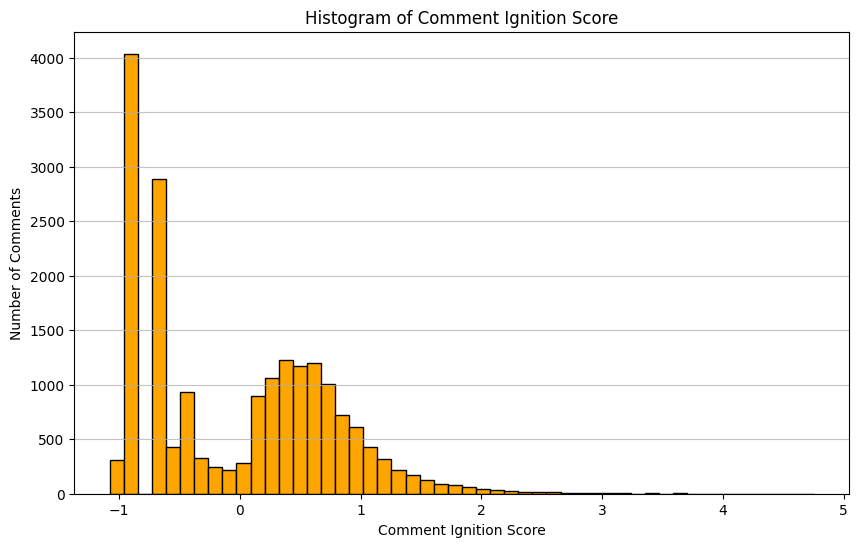

In [265]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(comments['comment_ignition_score'], bins=50, color='orange', edgecolor='black')
plt.title('Histogram of Comment Ignition Score')
plt.xlabel('Comment Ignition Score')
plt.ylabel('Number of Comments')
plt.grid(axis='y', alpha=0.75)
plt.show()

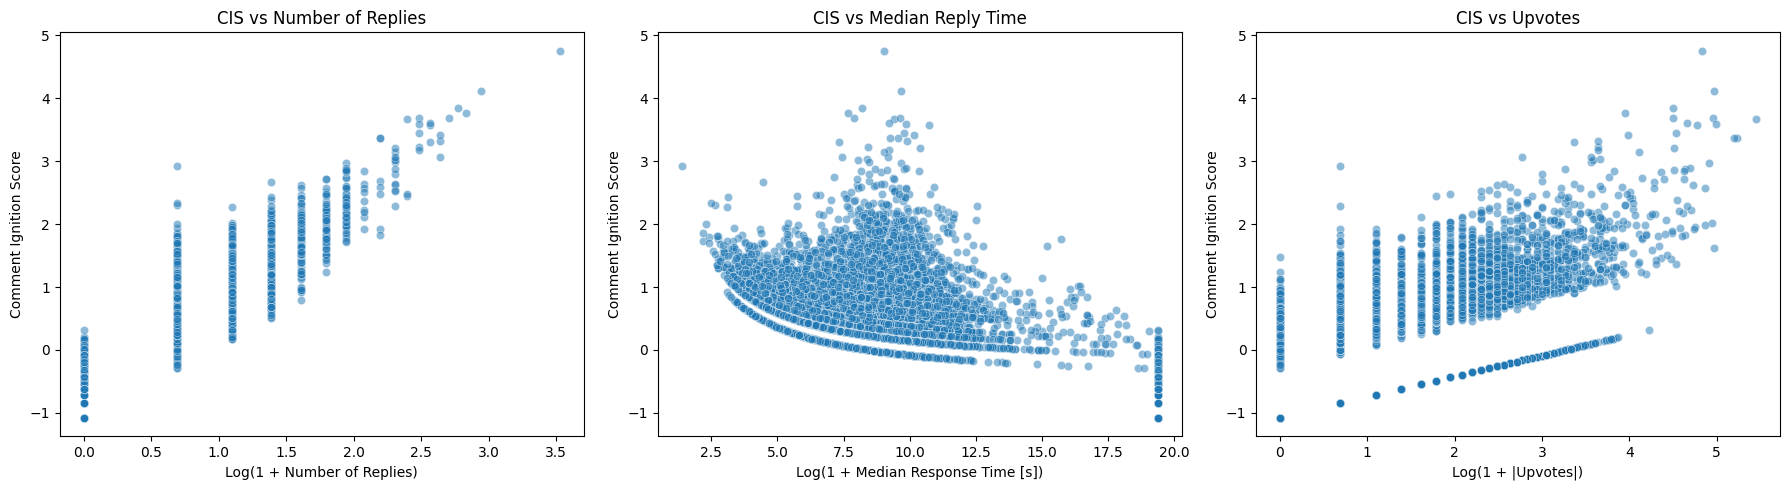

In [266]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_plot = comments[['comment_ignition_score', 'num_replies', 'median_reply_seconds', 'score']].copy()

df_plot['num_replies_log'] = np.log1p(df_plot['num_replies'])
df_plot['median_reply_seconds_log'] = np.log1p(df_plot['median_reply_seconds'])
df_plot['score_log'] = np.log1p(df_plot['score'].abs())

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(
    x='num_replies_log', y='comment_ignition_score', data=df_plot, ax=axes[0], alpha=0.5
)
axes[0].set_xlabel('Log(1 + Number of Replies)')
axes[0].set_ylabel('Comment Ignition Score')
axes[0].set_title('CIS vs Number of Replies')

sns.scatterplot(
    x='median_reply_seconds_log', y='comment_ignition_score', data=df_plot, ax=axes[1], alpha=0.5
)
axes[1].set_xlabel('Log(1 + Median Response Time [s])')
axes[1].set_ylabel('Comment Ignition Score')
axes[1].set_title('CIS vs Median Reply Time')

sns.scatterplot(
    x='score_log', y='comment_ignition_score', data=df_plot, ax=axes[2], alpha=0.5
)
axes[2].set_xlabel('Log(1 + |Upvotes|)')
axes[2].set_ylabel('Comment Ignition Score')
axes[2].set_title('CIS vs Upvotes')

plt.tight_layout()
plt.show()


C:\Users\marci\AppData\Local\Temp\ipykernel_22056\3305259729.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


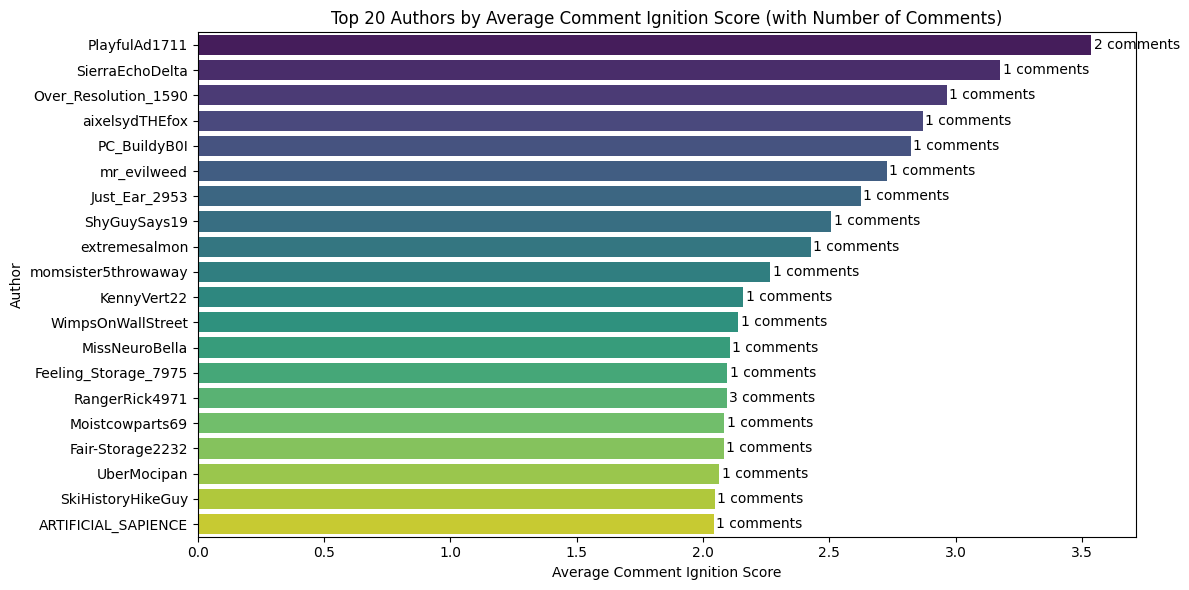

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns

author_stats = comments.groupby('author').agg(
    avg_cis=('comment_ignition_score', 'mean'),
    num_comments=('comment_ignition_score', 'count')
)

top10_authors = author_stats.sort_values('avg_cis', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top10_authors['avg_cis'], 
    y=top10_authors.index, 
    palette="viridis"
)

for i, (score, n_comments) in enumerate(zip(top10_authors['avg_cis'], top10_authors['num_comments'])):
    plt.text(score + 0.01, i, f"{n_comments} comments", va='center')

plt.xlabel("Average Comment Ignition Score")
plt.ylabel("Author")
plt.title("Top 20 Authors by Average Comment Ignition Score (with Number of Comments)")
plt.tight_layout()
plt.show()


In [110]:
his_timestamp = comments_df[comments_df['author'] == 'SierraEchoDelta']['timestamp'].values[0]
his_timestamp

np.datetime64('2023-11-23T03:54:07.000000000')

In [99]:
_my_comments = comments_df[comments_df['post_id'] == 't3_181ravl'].sort_values('timestamp')
_my_comments.head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited,post_id,parent_comments_ids,parent_comment_timestamp
5160,t1_kae59op,comment,2023-11-23 03:20:42+00:00,flatearth,PM-ME-YOUR-SOURCE,t3_181ravl,post,"Right, I forgot flat earthers only have cartoo...",https://www.reddit.com/r/flatearth/comments/18...,65,65,NaN,NaN,NaN,False,t3_181ravl,[],NaT
5164,t1_kae6zk9,comment,2023-11-23 03:34:30+00:00,flatearth,Remote_Work_8416,t3_181ravl,post,Jajajaja...no.,https://www.reddit.com/r/flatearth/comments/18...,12,12,NaN,NaN,NaN,False,t3_181ravl,[],NaT
5174,t1_kae76td,comment,2023-11-23 03:36:08+00:00,flatearth,zYbYz,t1_kae59op,comment,Ok then let’s see some round earth that’s not ...,https://www.reddit.com/r/flatearth/comments/18...,-60,-60,NaN,NaN,NaN,False,t3_181ravl,[t1_kae59op],2023-11-23T03:20:42+00:00
5198,t1_kae8gbp,comment,2023-11-23 03:46:22+00:00,flatearth,Xenon-Oxide,t1_kae76td,comment,Get a life loser,https://www.reddit.com/r/flatearth/comments/18...,30,30,NaN,NaN,NaN,False,t3_181ravl,"[t1_kae59op, t1_kae76td]",2023-11-23T03:36:08+00:00
5216,t1_kae8j6k,comment,2023-11-23 03:47:00+00:00,flatearth,zYbYz,t1_kae8gbp,comment,Still waiting,https://www.reddit.com/r/flatearth/comments/18...,-30,-30,NaN,NaN,NaN,False,t3_181ravl,"[t1_kae59op, t1_kae76td, t1_kae8gbp]",2023-11-23T03:46:22+00:00


In [114]:
temperatures = {
    pd.to_datetime(timestamp): get_temp_metric_to_timestamp('t3_181ravl', pd.to_datetime(timestamp))
    for timestamp in list(_my_comments['timestamp'])
}

In [111]:
his_timestamp

np.datetime64('2023-11-23T03:54:07.000000000')

In [117]:
temperatures

{Timestamp('2023-11-23 03:20:42+0000', tz='UTC'): post_id
 t3_181ravl    1.360266
 dtype: float64,
 Timestamp('2023-11-23 03:34:30+0000', tz='UTC'): post_id
 t3_181ravl    1.461632
 dtype: float64,
 Timestamp('2023-11-23 03:36:08+0000', tz='UTC'): post_id
 t3_181ravl    1.533552
 dtype: float64,
 Timestamp('2023-11-23 03:46:22+0000', tz='UTC'): post_id
 t3_181ravl    1.589338
 dtype: float64,
 Timestamp('2023-11-23 03:47:00+0000', tz='UTC'): post_id
 t3_181ravl    1.634919
 dtype: float64,
 Timestamp('2023-11-23 03:47:54+0000', tz='UTC'): post_id
 t3_181ravl    1.673456
 dtype: float64,
 Timestamp('2023-11-23 03:52:34+0000', tz='UTC'): post_id
 t3_181ravl    1.706839
 dtype: float64,
 Timestamp('2023-11-23 03:54:07+0000', tz='UTC'): post_id
 t3_181ravl    1.736285
 dtype: float64,
 Timestamp('2023-11-23 04:00:30+0000', tz='UTC'): post_id
 t3_181ravl    3.043058
 dtype: float64,
 Timestamp('2023-11-23 04:00:58+0000', tz='UTC'): post_id
 t3_181ravl    3.066885
 dtype: float64,
 Timestamp

In [ ]:
# import matplotlib.pyplot as plt

# timestamps = sorted(temperatures.keys())
# values = [temperatures[t] for t in timestamps]

# ref_value = temperatures[pd.Timestamp(his_timestamp, tz='UTC')]

# plt.figure(figsize=(8, 4))

# plt.plot(timestamps, values, marker="o", label="Metric")

# plt.axhline(
#     y=ref_value,
#     color="red",
#     linestyle="--",
#     linewidth=2,
#     label=f"Reference @ t={his_timestamp}"
# )

# plt.xlabel("Timestamp")
# plt.ylabel("Metric Value")
# plt.title("Temperature over Time with Reference Line")
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()

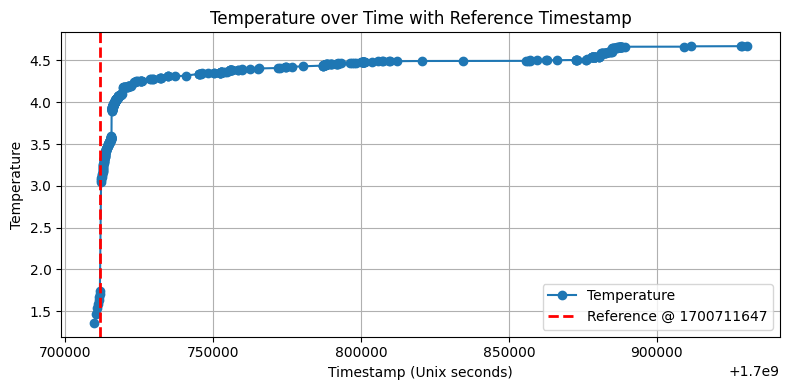

In [126]:
import matplotlib.pyplot as plt
import pandas as pd

timestamps = sorted(temperatures.keys())

timestamps_int = [int(t.timestamp()) for t in timestamps]
values = [temperatures[t] for t in timestamps]

ref_ts = pd.Timestamp(his_timestamp, tz="UTC")
ref_ts_int = int(ref_ts.timestamp())

plt.figure(figsize=(8, 4))

plt.plot(timestamps_int, values, marker="o", label="Temperature")

plt.axvline(
    x=ref_ts_int,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Reference @ {ref_ts_int}"
)

plt.xlabel("Timestamp (Unix seconds)")
plt.ylabel("Temperature")
plt.title("Temperature over Time with Reference Timestamp")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [120]:
temperatures.keys()

dict_keys([Timestamp('2023-11-23 03:20:42+0000', tz='UTC'), Timestamp('2023-11-23 03:34:30+0000', tz='UTC'), Timestamp('2023-11-23 03:36:08+0000', tz='UTC'), Timestamp('2023-11-23 03:46:22+0000', tz='UTC'), Timestamp('2023-11-23 03:47:00+0000', tz='UTC'), Timestamp('2023-11-23 03:47:54+0000', tz='UTC'), Timestamp('2023-11-23 03:52:34+0000', tz='UTC'), Timestamp('2023-11-23 03:54:07+0000', tz='UTC'), Timestamp('2023-11-23 04:00:30+0000', tz='UTC'), Timestamp('2023-11-23 04:00:58+0000', tz='UTC'), Timestamp('2023-11-23 04:02:10+0000', tz='UTC'), Timestamp('2023-11-23 04:03:50+0000', tz='UTC'), Timestamp('2023-11-23 04:04:22+0000', tz='UTC'), Timestamp('2023-11-23 04:08:12+0000', tz='UTC'), Timestamp('2023-11-23 04:10:11+0000', tz='UTC'), Timestamp('2023-11-23 04:11:49+0000', tz='UTC'), Timestamp('2023-11-23 04:12:05+0000', tz='UTC'), Timestamp('2023-11-23 04:12:37+0000', tz='UTC'), Timestamp('2023-11-23 04:13:12+0000', tz='UTC'), Timestamp('2023-11-23 04:13:22+0000', tz='UTC'), Timestamp